In [1]:
# %pip install langchain-anthropic

In [2]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode
import os
import getpass

In [3]:
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "seo-page-optimizer"

In [4]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)

In [5]:
from agents.optimizers.page_analyzer import PageAnalyzer
from agents.optimizers.design_instructor import DesignInstructor
from agents.optimizers.drafter import Drafter
from agents.optimizers.eeat_analyzer import EEATAnalyzer
from agents.optimizers.eeat_revisor import EEATRevisor
from agents.optimizers.scraper import WebsiteScraper


from agents.optimizers.knowledge_retriever import KnowledgeRetriever
from agents.optimizers.facts_retreiver import FactsRetriever
from agents.optimizers.wireframe_creator import WireFrameCreator

# create agents
page_analyzer= PageAnalyzer(
    model="gpt-4o-mini",
    server="openai"
)

design_instructor= DesignInstructor(
    model= "gpt-4o-mini",
    server= "openai"

)

drafter= Drafter(
    model= "claude-3-5-sonnet-latest",
    server="claude",
    temperature=0.2
)

eeat_analyzer= EEATAnalyzer(

    model= "claude-3-5-sonnet-latest",
    server="claude",
    temperature=0.2
)

eeat_revisor= EEATRevisor(
   model= "claude-3-5-sonnet-latest",
    server="claude",
    temperature=0.2
)

knowledge_retriever= KnowledgeRetriever(
    model= "gpt-4o-mini",
    server= "openai",
)

facts_retriever= FactsRetriever(
    model= "perplexity"

)

wireframe_creator= WireFrameCreator(
    model= "gpt-4o-mini",
    server= "openai"
)

scraper= WebsiteScraper()



USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
#workflow
from langgraph.graph import StateGraph, MessagesState, START, END
from workflow.state import AgentGraphState


workflow = StateGraph(AgentGraphState)

workflow.add_node("website_scraper", scraper.scrape_webpages)
workflow.add_node("knowledge_retriever", knowledge_retriever.create_agent_graph)
workflow.add_node("page_analyzer", page_analyzer.invoke)
workflow.add_node("design_instructor", design_instructor.invoke)
workflow.add_node("drafter", drafter.invoke)
workflow.add_node("eeat_analyzer", eeat_analyzer.invoke)
workflow.add_node("eeat_revisor", eeat_revisor.invoke)
workflow.add_node("wire_frame_creator", wireframe_creator.invoke)

workflow.add_edge(START, "website_scraper")
workflow.add_edge("website_scraper","page_analyzer" )
workflow.add_edge("page_analyzer", "design_instructor")
workflow.add_edge("design_instructor", "drafter")
workflow.add_edge("drafter", "eeat_analyzer")
workflow.add_edge("drafter","wire_frame_creator")
workflow.add_edge("eeat_analyzer", "eeat_revisor")
workflow.add_edge("eeat_revisor",END)
workflow.add_edge("wire_frame_creator", END)

graph = workflow.compile()

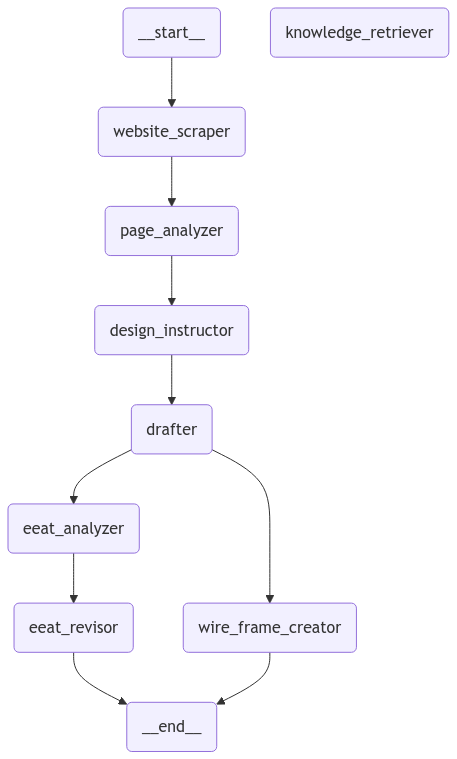

In [7]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [8]:
graph.invoke({
    "target_keywords":["freelance business"],
    "url_to_scrape": "https://www.datalumina.com/",
    "brand_knowledge":"",
    "keyword_knowledge":""
})

website  https://www.datalumina.com/
docs [Document(metadata={'source': 'https://www.datalumina.com/', 'title': 'Data Beyond Boundaries | Datalumina', 'description': 'We blend years of tech expertise with a fresh, agile approach to solve your most complex challenges. From streamlining operations to training your team in AI mastery, we are here to light up your path to success.', 'language': 'en'}, page_content="Data Beyond Boundaries | DataluminaDataluminaServicesinsightsaboutAcademyGenAI LaunchpadContactContactGenAI Launchpad is now availableTransforming complexity into capabilityAI and data reshape our world at a relentless speed, yet most find themselves caught between possibility and complexity. We are here to help you identify what truly gives that competitive advantage.ServicesAcademyServicesFrom building enterprise-grade AI platforms to guiding digital transformation and upskilling development teams, we help you move beyond any boundaries of what's possible, pointing you to AI a

{'target_keywords': ['freelance business'],
 'url_to_scrape': 'https://www.datalumina.com/',
 'messages': [],
 'scraped_website_content': "Data Beyond Boundaries | DataluminaDataluminaServicesinsightsaboutAcademyGenAI LaunchpadContactContactGenAI Launchpad is now availableTransforming complexity into capabilityAI and data reshape our world at a relentless speed, yet most find themselves caught between possibility and complexity. We are here to help you identify what truly gives that competitive advantage.ServicesAcademyServicesFrom building enterprise-grade AI platforms to guiding digital transformation and upskilling development teams, we help you move beyond any boundaries of what's possible, pointing you to AI and data technologies that make sense in helping you grow.DataluminaDevelopment01Custom AI solutions & data platformsWhether it's data warehousing or intelligent systems, we architect and implement scalable solutions that transform complex problems into competitive advantages 